In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if files:
        print("   Files:", len(files))

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/emmarex
/kaggle/input/datasets/emmarex/plantdisease
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot
   Files: 997
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Potato___healthy
   Files: 152
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Leaf_Mold
   Files: 952
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
   Files: 3209
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Bacterial_spot
   Files: 2127
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Septoria_leaf_spot
   Files: 1771
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_healthy
   Files: 1591
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite
   Files: 1676
/kaggle/input/datasets/emmarex/plantdisease/Plant

In [2]:
import os

DATA_DIR = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

classes = []
total_images = 0

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        classes.append(class_name)

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        total_images += count

print("Number of classes:", len(classes))
print("Total images:", total_images)

print("\nClasses:")
for i, cls in enumerate(classes):
    print(i, cls)

Number of classes: 15
Total images: 20638

Classes:
0 Pepper__bell___Bacterial_spot
1 Pepper__bell___healthy
2 Potato___Early_blight
3 Potato___Late_blight
4 Potato___healthy
5 Tomato_Bacterial_spot
6 Tomato_Early_blight
7 Tomato_Late_blight
8 Tomato_Leaf_Mold
9 Tomato_Septoria_leaf_spot
10 Tomato_Spider_mites_Two_spotted_spider_mite
11 Tomato__Target_Spot
12 Tomato__Tomato_YellowLeaf__Curl_Virus
13 Tomato__Tomato_mosaic_virus
14 Tomato_healthy


,Class,Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


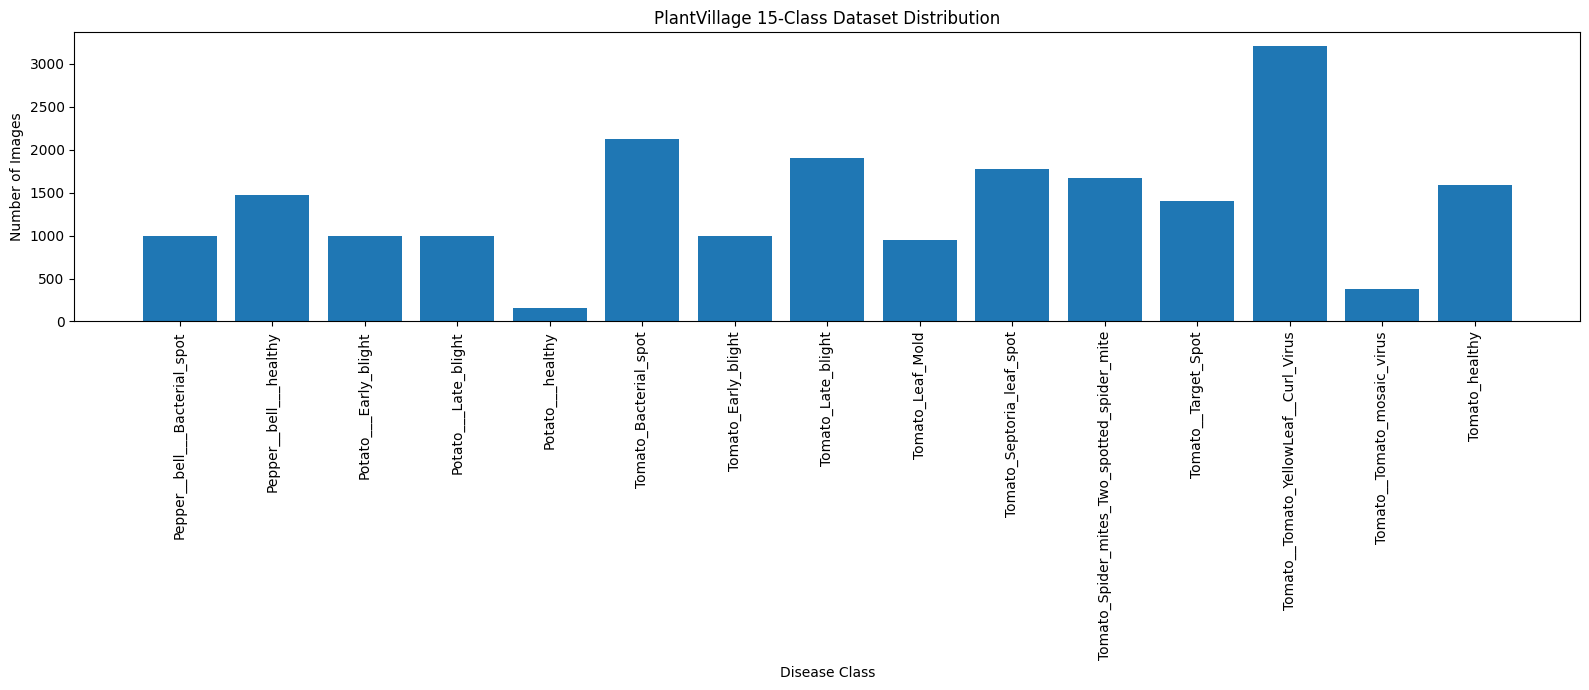

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

class_counts = {}

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    class_counts[class_name] = count

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Images"]
)

display(df_counts)

plt.figure(figsize=(16, 7))
plt.bar(df_counts["Class"], df_counts["Images"])

plt.xticks(rotation=90)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("PlantVillage 15-Class Dataset Distribution")

plt.tight_layout()
plt.show()

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
class_names = sorted([
    folder
    for folder in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, folder))
])

num_classes = len(class_names)

print("Number of classes:", num_classes)

print("\nClass names:")

for i, class_name in enumerate(class_names):
    print(i, ":", class_name)
    

Number of classes: 15

Class names:
0 : Pepper__bell___Bacterial_spot
1 : Pepper__bell___healthy
2 : Potato___Early_blight
3 : Potato___Late_blight
4 : Potato___healthy
5 : Tomato_Bacterial_spot
6 : Tomato_Early_blight
7 : Tomato_Late_blight
8 : Tomato_Leaf_Mold
9 : Tomato_Septoria_leaf_spot
10 : Tomato_Spider_mites_Two_spotted_spider_mite
11 : Tomato__Target_Spot
12 : Tomato__Tomato_YellowLeaf__Curl_Virus
13 : Tomato__Tomato_mosaic_virus
14 : Tomato_healthy


In [7]:
total_images = 0

class_counts = {}

for class_name in class_names:

    class_path = os.path.join(DATA_DIR, class_name)

    image_files = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    count = len(image_files)

    class_counts[class_name] = count

    total_images += count

print("Total images:", total_images)

Total images: 20638


In [8]:
class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

display(class_distribution)

,Class,Number of Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


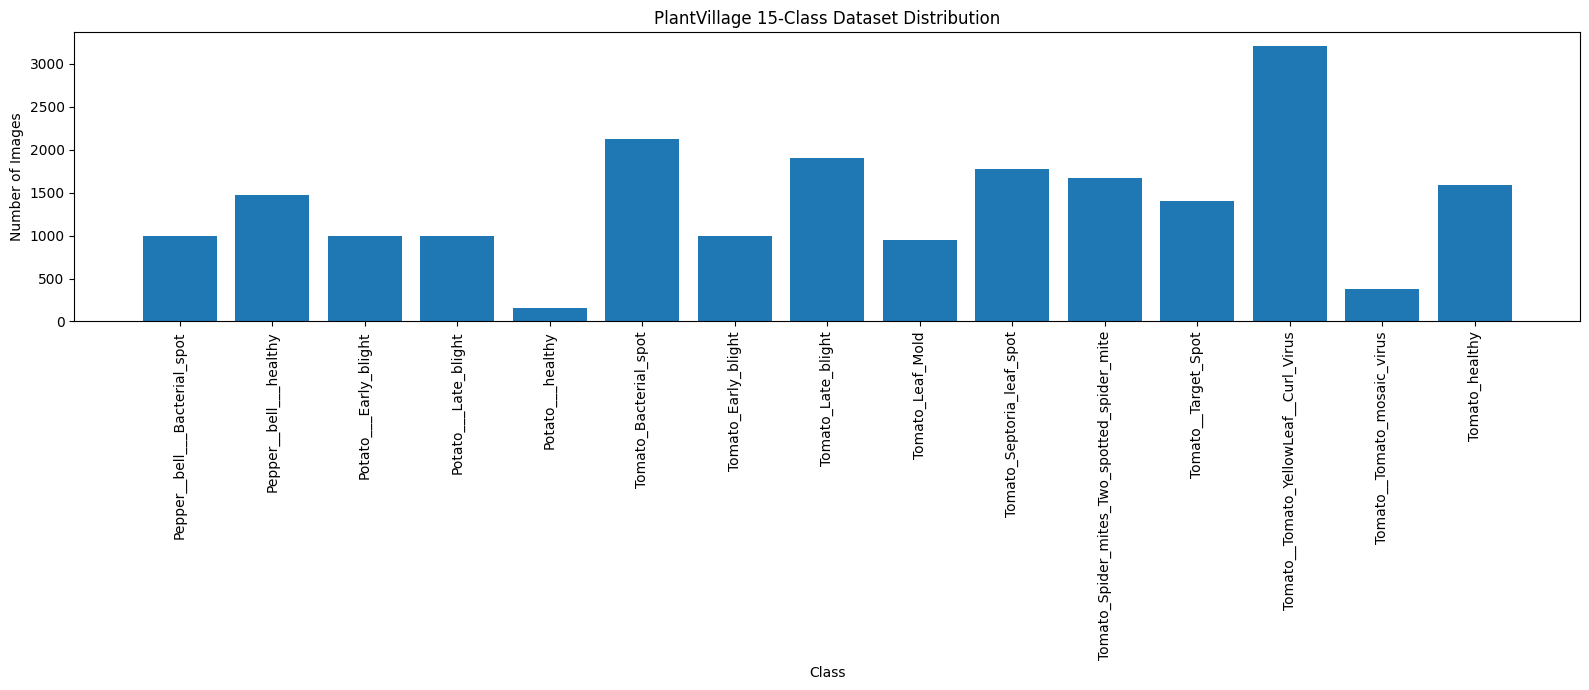

In [9]:
plt.figure(figsize=(16, 7))

plt.bar(
    class_distribution["Class"],
    class_distribution["Number of Images"]
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("PlantVillage 15-Class Dataset Distribution")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

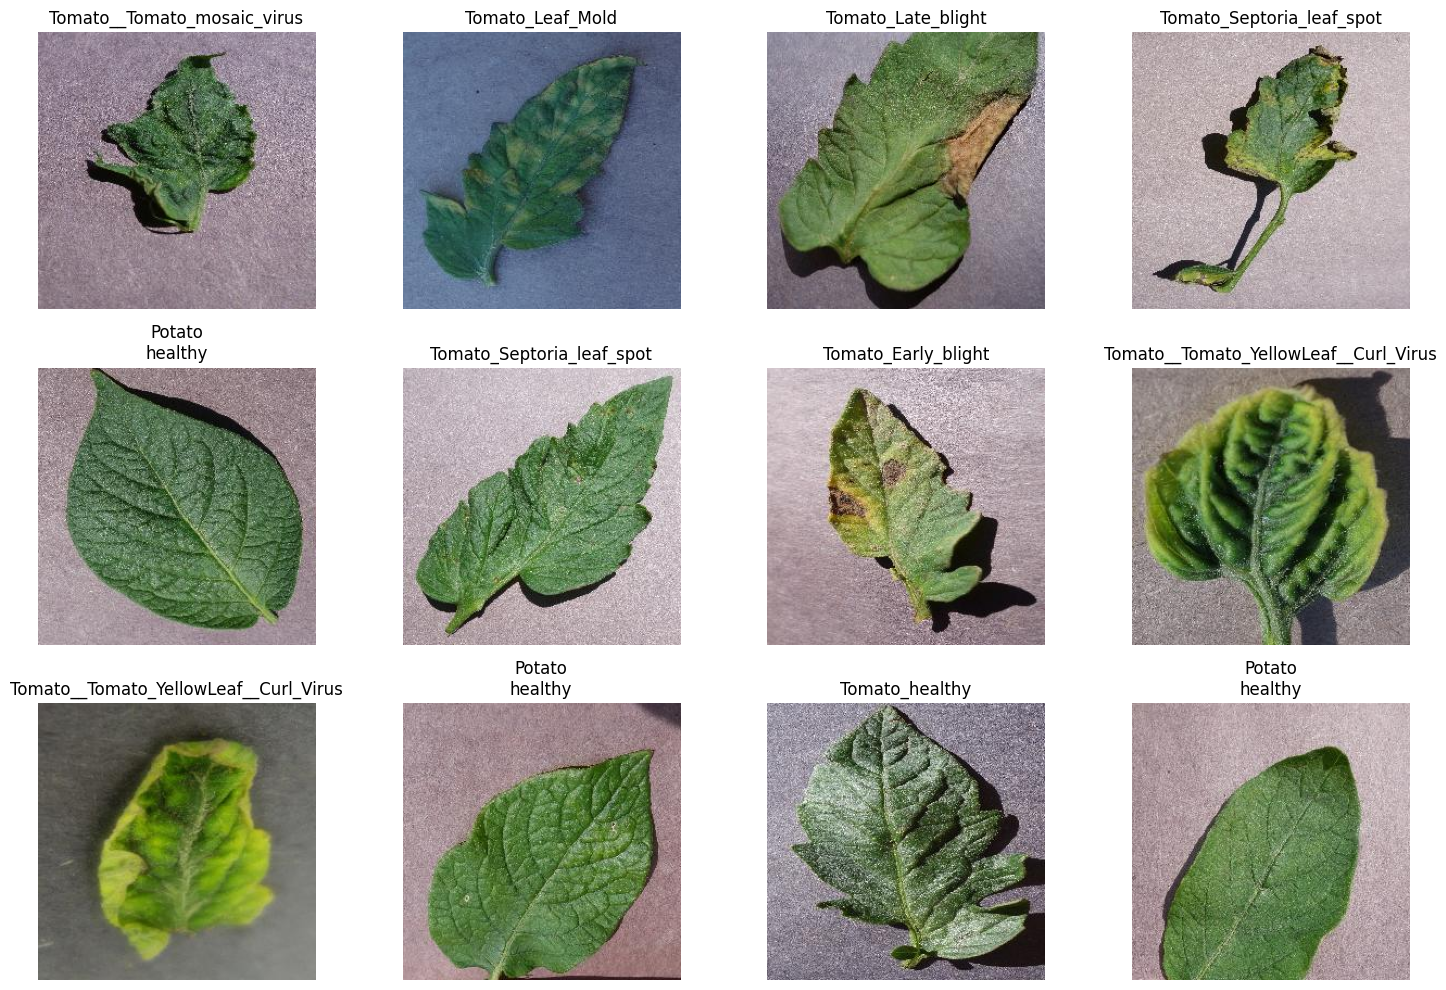

In [10]:
import random
from PIL import Image

plt.figure(figsize=(15, 10))

for i in range(12):

    # Select random class
    class_name = random.choice(class_names)

    class_path = os.path.join(DATA_DIR, class_name)

    # Get image files
    image_files = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Select random image
    image_file = random.choice(image_files)

    image_path = os.path.join(class_path, image_file)

    # Open image
    image = Image.open(image_path)

    # Display
    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(class_name.replace("___", "\n"))

    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
tf.keras.utils.image_dataset_from_directory()

TypeError: image_dataset_from_directory() missing 1 required positional argument: 'directory'

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 20638 files belonging to 15 classes.
Using 14447 files for training.


In [13]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 20638 files belonging to 15 classes.
Using 6191 files for validation.


In [14]:
val_batches = tf.data.experimental.cardinality(validation_dataset)

test_size = val_batches // 2

test_dataset = validation_dataset.take(test_size)

validation_dataset = validation_dataset.skip(test_size)

print("Dataset split completed.")

Dataset split completed.


In [15]:
train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
val_batches = tf.data.experimental.cardinality(validation_dataset).numpy()
test_batches = tf.data.experimental.cardinality(test_dataset).numpy()

print("Training batches:", train_batches)
print("Validation batches:", val_batches)
print("Testing batches:", test_batches)

print("\nApproximate images:")

print("Training:", train_batches * BATCH_SIZE)
print("Validation:", val_batches * BATCH_SIZE)
print("Testing:", test_batches * BATCH_SIZE)

Training batches: 452
Validation batches: 97
Testing batches: 97

Approximate images:
Training: 14464
Validation: 3104
Testing: 3104


In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Input pipeline optimized.")

Input pipeline optimized.


In [17]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

print("Data augmentation created.")

Data augmentation created.


In [18]:
base_model = tf.keras.applications.EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("EfficientNetV2B0 loaded successfully.")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetV2B0 loaded successfully.


In [19]:
base_model.trainable = False

print("EfficientNetV2B0 backbone frozen.")

EfficientNetV2B0 backbone frozen.


In [20]:
inputs = keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# EfficientNetV2 feature extraction
x = base_model(x, training=False)

# Convert feature maps into a feature vector
x = layers.GlobalAveragePooling2D()(x)

# Reduce overfitting
x = layers.Dropout(0.3)(x)

# Final classifier
outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

print("Model created successfully.")

Model created successfully.


In [21]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,938,527 (22.65 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [23]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Early stopping created.")

Early stopping created.


In [24]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.7183 - loss: 1.0164 - val_accuracy: 0.8746 - val_loss: 0.5100
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.8553 - loss: 0.5043 - val_accuracy: 0.9086 - val_loss: 0.3524
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 450s 995ms/step - accuracy: 0.8800 - loss: 0.4011 - val_accuracy: 0.9151 - val_loss: 0.2945
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 444s 983ms/step - accuracy: 0.8995 - loss: 0.3492 - val_accuracy: 0.9297 - val_loss: 0.2453
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 451s 997ms/step - accuracy: 0.9100 - loss: 0.3116 - val_accuracy: 0.9365 - val_loss: 0.2234
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 437s 967ms/step - accuracy: 0.9131 - loss: 0.2902 - val_accuracy: 0.9430 - val_loss: 0.2024
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 442s 979ms/step - accuracy: 0.9153 - loss: 0.2745 - val_accuracy: 0.9391 - val_loss: 0.2023
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 520s 1s/step - accuracy: 0.9198 - loss: 0.

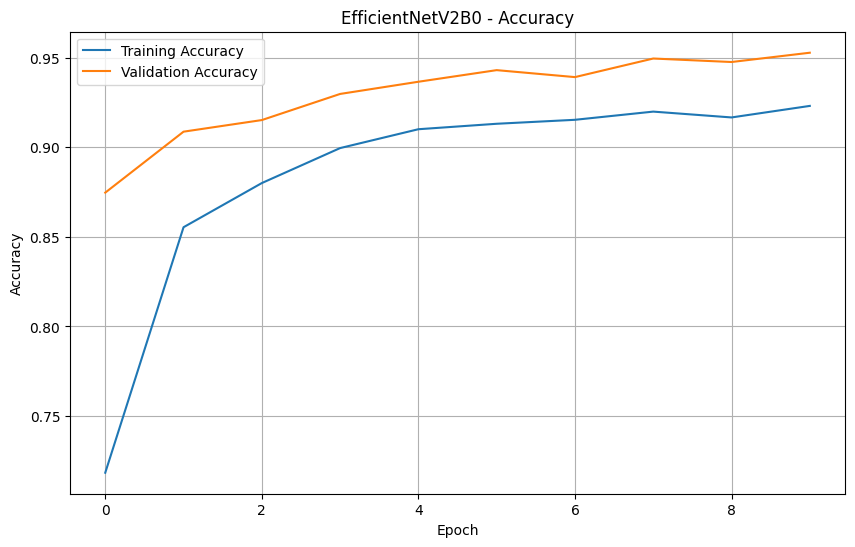

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetV2B0 - Accuracy")

plt.legend()
plt.grid(True)

plt.show()

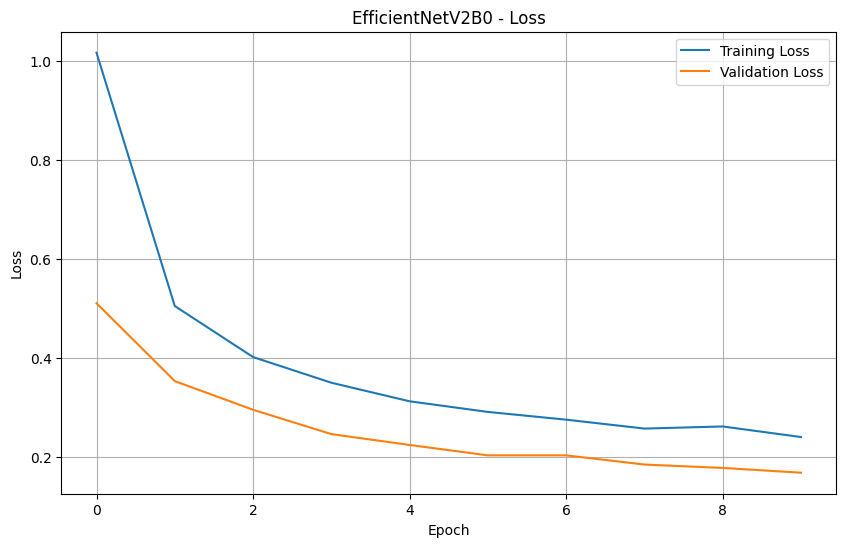

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetV2B0 - Loss")

plt.legend()
plt.grid(True)

plt.show()

In [27]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

97/97 ━━━━━━━━━━━━━━━━━━━━ 75s 768ms/step - accuracy: 0.9481 - loss: 0.1771
Test Loss: 0.17711520195007324
Test Accuracy: 0.9481314420700073
Test Accuracy (%): 94.81314420700073


In [28]:
model.save(
    "/kaggle/working/EfficientNetV2B0_PlantVillage.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [29]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test images:", len(y_true))
print("Predictions generated successfully.")

Number of test images: 3104
Predictions generated successfully.


In [30]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9809    1.0000    0.9904       154
                     Pepper__bell___healthy     0.9957    0.9915    0.9936       234
                      Potato___Early_blight     0.9662    0.9931    0.9795       144
                       Potato___Late_blight     0.9737    0.9548    0.9642       155
                           Potato___healthy     0.8788    1.0000    0.9355        29
                      Tomato_Bacterial_spot     0.9366    0.9873    0.9612       314
                        Tomato_Early_blight     0.9280    0.8112    0.8657       143
                         Tomato_Late_blight     0.9430    0.9219    0.9323       269
                           Tomato_Leaf_Mold     0.9549    0.9071    0.9304       140
                  Tomato_Septoria_leaf_spot     0.9603    0.8963    0.9272       270
Tomato_Spider_mites_Two_spotted_spider_mite     0.9170    0.9067

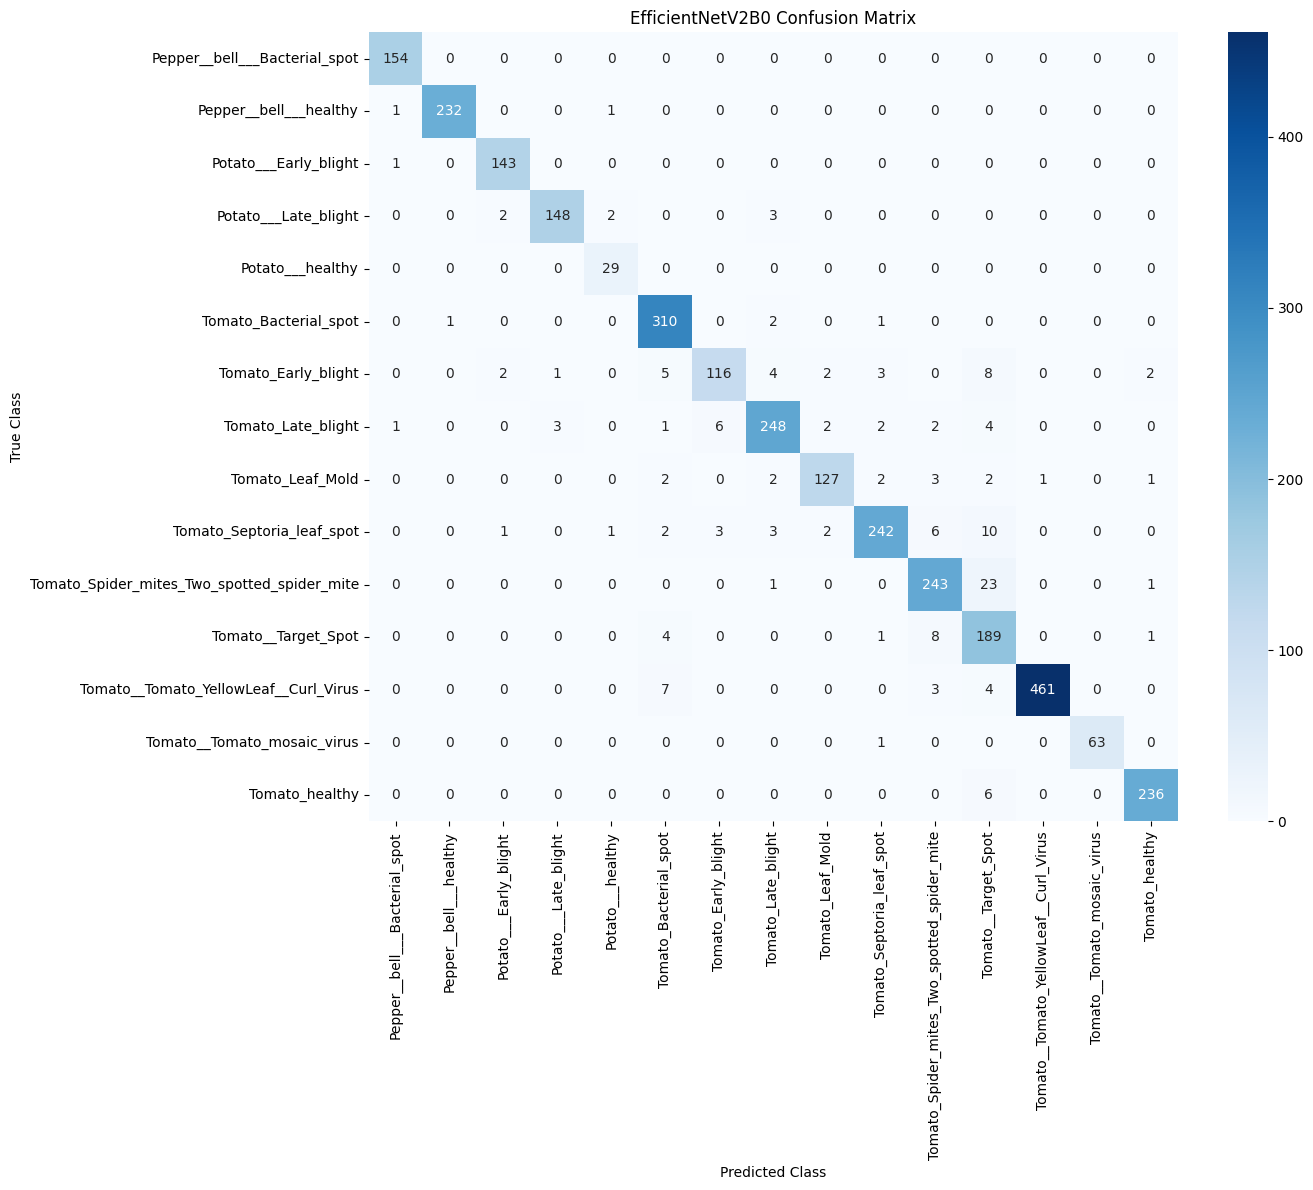

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("EfficientNetV2B0 Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print("===== EfficientNetV2B0 Results =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

===== EfficientNetV2B0 Results =====
Accuracy : 0.9475
Precision: 0.9454
Recall   : 0.9487
F1-score : 0.9458


In [34]:
results = pd.DataFrame({
    "Model": ["EfficientNetV2B0"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1]
})

display(results)

,Model,Accuracy,Precision,Recall,F1_Score
0,EfficientNetV2B0,0.947487,0.945358,0.948735,0.945795


In [35]:
results.to_csv(
    "/kaggle/working/EfficientNetV2B0_results.csv",
    index=False
)

print("Results saved.")

Results saved.
